# `CoxProcess`: a Poisson process whose rate is itself random

A Poisson process has one rate, forever. A non-homogeneous Poisson process has
a rate that changes over time, but it changes the *same way* every time you
simulate it. A **Cox process** draws the rate at random first, and only then
generates events at it -- so two simulated paths can be busy or quiet for
entirely different reasons.

    step 1:  draw a whole intensity          (a number, or a whole path)
    step 2:  generate events at that rate    (a Poisson process, given step 1)

This is the standard way to model counts that vary *more* than a Poisson
process allows: claims from drivers who are not equally careful, calls on days
that are not equally busy, defaults in an economy that switches between calm
and stressed. It is also one mechanism covering several named models -- which
one you get depends entirely on what you pass as `intensity`.

In [1]:
import numpy as np

from symbulate import *
from symbulate import distributions, markov_chains, diffusion_process


def seed(value=42):
    """Make the draws below reproducible.

    Each module that generates randomness has its own generator, so an
    intensity drawn from a Markov chain or a diffusion needs that module
    reseeded too -- none of them read NumPy's global generator.
    """
    distributions.rng = np.random.default_rng(value)
    markov_chains.rng = np.random.default_rng(value)
    diffusion_process.rng = np.random.default_rng(value)

## One random rate: the mixed Poisson process

The simplest random intensity is a single number, drawn once and held for the
whole path. Pass a **distribution** and that is what you get.

Here is a fleet of drivers who are not equally accident-prone. Each driver's
own accident rate is drawn from a gamma distribution averaging 0.5 per year;
then accidents happen at *that* driver's rate.

In [2]:
drivers = CoxProcess(intensity=Gamma(shape=2, rate=4))

seed()
driver = drivers.draw()
round(driver.intensity, 3)  # this driver's own rate

0.523

Every path keeps the intensity it was generated at, as `.intensity`. That is
worth looking at: it is the thing that distinguishes a Cox process from a
Poisson process with the same average rate.

The path itself counts events, exactly like any other counting process.

In [3]:
[driver(t) for t in [1, 2, 5, 10]]  # accidents by year 1, 2, 5, 10

[0, 0, 1, 4]

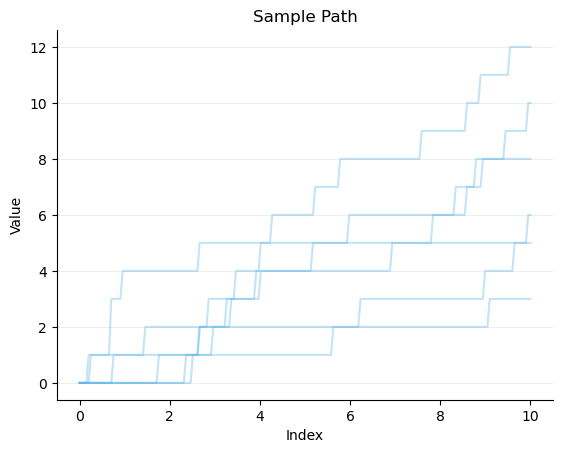

In [4]:
seed()
drivers.sim(6).plot(tmin=0, tmax=10)

Some of those staircases climb steeply and some stay almost flat, and the
reason is not luck in the arrivals -- it is that they are different drivers.

The expected count for *this* driver is the rate times the time, which the path
will tell you as `cumulative_rate(t)`:

In [5]:
seed()
driver = drivers.draw()
print(f"this driver's rate:            {driver.intensity:.3f}")
print(f"expected accidents by year 10: {driver.cumulative_rate(10):.3f}")
print(f"actual accidents by year 10:   {driver(10)}")

this driver's rate:            0.523
expected accidents by year 10: 5.230
actual accidents by year 10:   4


### Why bother: the counts are overdispersed

Averaged over drivers the rate is `2 / 4 = 0.5` per year, so a Poisson process
at rate 0.5 has the same mean count. It does *not* have the same spread.

With a `Gamma(shape=r, rate=beta)` intensity the count by time `t` has a
**negative binomial** distribution -- `r` successes with probability
`beta / (beta + t)` -- the classic overdispersed alternative to the Poisson.
Both its mean and its variance are known in closed form, so the simulation can
be checked rather than merely admired.

In [6]:
seed()
cox_counts = drivers[5].sim(10000)
seed()
poisson_counts = PoissonProcess(rate=0.5)[5].sim(10000)

mean = 2 * 5 / 4
print("                 mean    variance")
print(f"Cox        {cox_counts.mean():10.3f}  {cox_counts.var():10.3f}")
print(f"Poisson    {poisson_counts.mean():10.3f}  {poisson_counts.var():10.3f}")
print(f"theory     {mean:10.3f}  {mean + 2 * (5 / 4) ** 2:10.3f}")

                 mean    variance
Cox             2.521       5.486


Poisson         2.508       2.528
theory          2.500       5.625


Same mean, roughly twice the variance. The extra variance is exactly the
variance of the random expected count -- the spread in the drivers themselves.

It shows up in the shape too: more drivers with no accidents at all, *and* more
drivers with a lot of them.

Currently Showing: Impulse Plot (Default)
Alternative Plots: Histogram (type = "hist"), Dot Plot (type = "dotplot"), ECDF Plot (type = "ecdf")


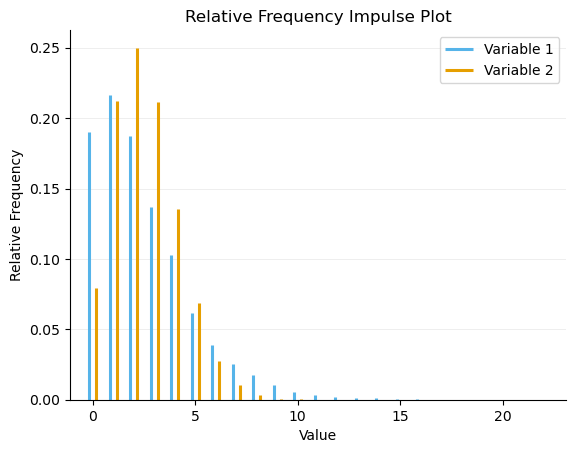

In [7]:
cox_counts.plot()
poisson_counts.plot()

## A rate that switches regimes: the Markov-modulated Poisson process

Pass a **random process** instead of a distribution and the rate varies over
time -- randomly, and differently on every path.

A continuous-time Markov chain is the natural choice when the world switches
between a few regimes: calm and stressed, quiet and busy, off-peak and peak.
Label its states with the rates themselves and you have the Markov-modulated
Poisson process from the actuarial literature.

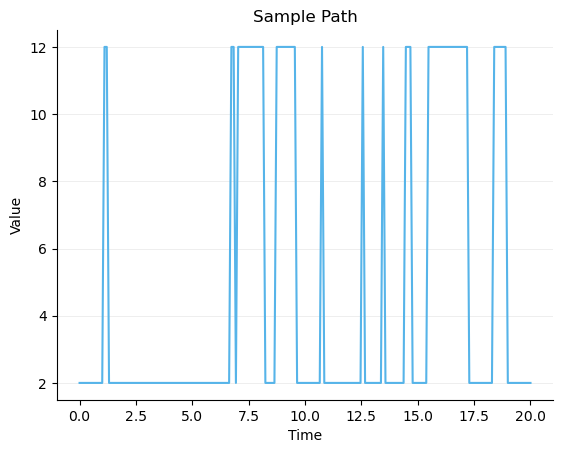

In [8]:
quiet_and_busy = ContinuousTimeMarkovChain(
    [[-1, 1], [1.5, -1.5]],  # leaves quiet at rate 1, leaves busy at rate 1.5
    [1.0, 0.0],  # starts quiet
    state_labels=[2, 12],  # 2 calls an hour when quiet, 12 when busy
)

calls = CoxProcess(intensity=quiet_and_busy)

seed(1)
day = calls.draw()
day.intensity.plot(tmin=0, tmax=20)

That is the intensity, not the counts: the call rate for this one day, jumping
between 2 and 12 as the switchboard gets busy and quiets down again.

The counts follow it. Steep stretches of the staircase below line up with the
high stretches of the intensity above.

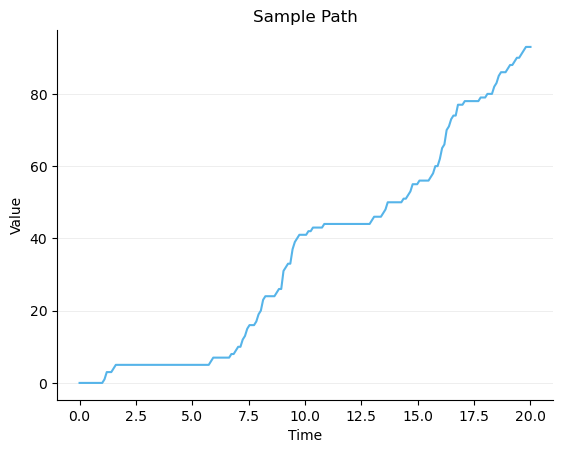

In [9]:
day.plot(tmin=0, tmax=20)

### This case is exact

An intensity that holds one value at a time has nothing to approximate: the
expected number of calls is a sum of rate times how long that rate was held.
Symbulate adds it up that way, so `cumulative_rate` agrees with the sum you
would do by hand to the last decimal place.

In [10]:
by_hand = 0.0
elapsed = 0.0
print(" n   rate   held for   until   expected calls so far")
for n in range(6):
    rate = day.intensity.states[n]
    held = float(day.intensity.interarrival_times[n])
    by_hand += rate * held
    elapsed += held
    print(f"{n:2}   {rate:4}   {held:8.3f}   {elapsed:5.2f}   {by_hand:20.3f}")

print()
print(f"by hand:          {by_hand:.10f}")
print(f"cumulative_rate:  {day.cumulative_rate(elapsed):.10f}")

 n   rate   held for   until   expected calls so far
 0      2      1.073    1.07                  2.146
 1     12      0.206    1.28                  4.614
 2      2      5.375    6.65                 15.365
 3     12      0.244    6.90                 18.296
 4      2      0.115    7.01                 18.527
 5     12      1.200    8.21                 32.925

by hand:          32.9250746176
cumulative_rate:  32.9250746176


## A rate that wanders: a diffusion intensity

The third kind of intensity changes continuously rather than in jumps. A CIR
process is the usual choice, because it is pulled back toward a long-run level
and never goes negative -- both of which an intensity needs.

This is the one case Symbulate has to **approximate**. A wandering path has no
formula for its integral, so the intensity is read every `step` units of time
and held at each reading, which is the left-hand sum you would draw by hand.
`step` defaults to 0.01; smaller is more accurate and slower. (The two cases
above ignore it entirely, being exact.)

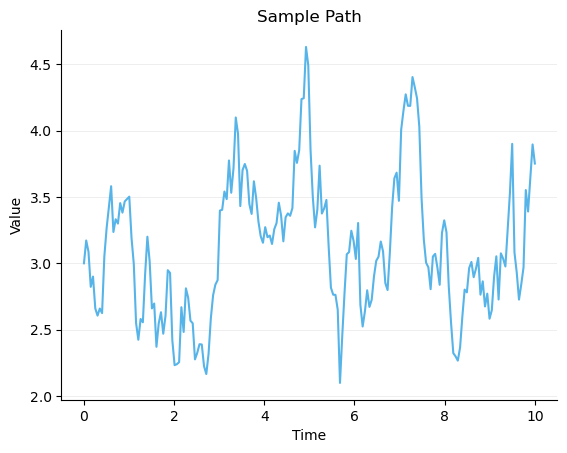

In [11]:
wandering_rate = CIR(reversion_rate=1, mean=3, scale=0.6)
defaults = CoxProcess(intensity=wandering_rate, step=0.02)

seed(3)
year = defaults.draw()
year.intensity.plot(tmin=0, tmax=10)

In [12]:
print(f"intensity at time 2:       {year.intensity(2):.3f}")
print(f"expected events by time 2: {year.cumulative_rate(2):.3f}")
print(f"actual events by time 2:   {year(2)}")

intensity at time 2:       2.335
expected events by time 2: 5.913
actual events by time 2:   8


A CIR process started at its long-run mean has that mean as its expected value
at every time, so the expected count by time `t` is just `mean * t` -- which
gives something to check the approximation against.

In [13]:
seed(3)
simulated = defaults[2].sim(2000)
print(f"simulated mean count by time 2: {simulated.mean():.3f}")
print(f"expected (mean * t = 3 * 2):    {6.0:.3f}")

simulated mean count by time 2: 6.072
expected (mean * t = 3 * 2):    6.000


## What an intensity cannot be

An intensity is a rate of events, so it can never be negative. A process that
wanders below 0 -- Brownian motion, say -- is not usable as it stands, and
saying so at the time it happens is more useful than a count of `nan` events.

In [14]:
try:
    CoxProcess(intensity=BrownianMotion())[5].draw()
except ValueError as error:
    print(error)

At time 0.01, the intensity is -0.0878248, but an intensity can never be negative -- it is how frequently events happen, so 0 is the smallest it can be (no events at all just then). A process that goes negative, such as BrownianMotion, cannot be an intensity as it stands. Use one that stays nonnegative -- CIR(), GeometricBrownianMotion(), or a ContinuousTimeMarkovChain whose states are nonnegative rates -- or square it, exponentiate it, or otherwise send it through a function that cannot go below 0.


A distribution that can go negative is caught even earlier -- when the process
is built, before anything is simulated -- since its support says so outright.

In [15]:
try:
    CoxProcess(intensity=Normal(mean=5, sd=2))
except ValueError as error:
    print(error)

intensity must never be negative, but Normal can produce values as small as -inf. The intensity is how frequently events happen, so 0 is the smallest it can be. Try a distribution that is never negative, such as Gamma(shape=2, rate=1), Exponential(rate=1), or LogNormal(0, 1).


## Turning the randomness off

Passing a plain function of time, or a plain number, gives a rate that is not
random at all. That is an ordinary non-homogeneous (or ordinary) Poisson
process, and it is worth having for exactly one reason: it lets you put the
random-rate and fixed-rate versions of a model side by side.

In [16]:
fixed = CoxProcess(intensity=lambda t: 2 * t)
print(f"expected events by time 3: {fixed.draw().cumulative_rate(3)}")

seed()
constant = CoxProcess(intensity=0.5)[5].sim(10000)
print(f"constant rate 0.5 -- mean and variance of N(5): "
      f"{constant.mean():.3f}, {constant.var():.3f}")

expected events by time 3: 9.0
constant rate 0.5 -- mean and variance of N(5): 2.508, 2.528


Mean and variance both about 2.5 -- a Poisson process, no overdispersion. Put
that next to the `Cox` row in the table further up, where the same mean came
with twice the variance, and you have the point of the whole process in two
numbers.

## Summary

| `intensity=` | What you get | Exact? |
|---|---|---|
| a distribution | mixed Poisson process (gamma → negative binomial counts) | yes |
| a continuous-time Markov chain | Markov-modulated Poisson process | yes |
| a Poisson or renewal count | a rate that only ever rises | yes |
| a diffusion (`CIR`, ...) | a continuously wandering rate | read every `step` |
| a function of time, or a number | non-homogeneous (or ordinary) Poisson process | yes |

Every path keeps `.intensity`, the rate it was generated at, and
`.cumulative_rate(t)`, the expected count by time `t` given that rate. Plot the
first and the process stops being a black box.